In [100]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [101]:
imagen_iphone = cv2.imread('iphone14.jpeg')
imagen_iphone = cv2.cvtColor(imagen_iphone, cv2.COLOR_BGR2RGB)

imagen_chris = cv2.imread('chris.jpeg')
imagen_chris = cv2.cvtColor(imagen_chris, cv2.COLOR_BGR2RGB)

imagen_chica = cv2.imread('chica.jpeg')
imagen_chica = cv2.cvtColor(imagen_chica, cv2.COLOR_BGR2RGB)

I_iphone = cv2.cvtColor(imagen_iphone, cv2.COLOR_RGB2GRAY)
I_chris = cv2.cvtColor(imagen_chris, cv2.COLOR_RGB2GRAY)
I_chica = cv2.cvtColor(imagen_chica, cv2.COLOR_RGB2GRAY)

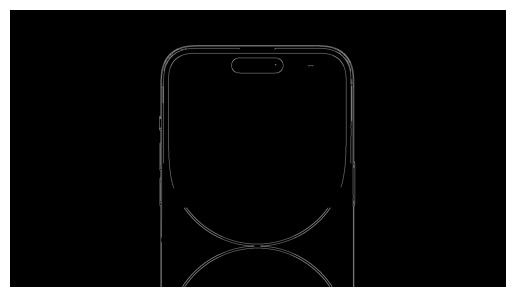

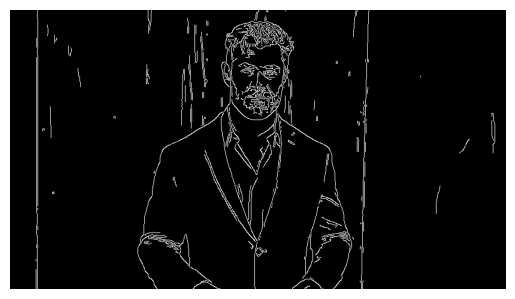

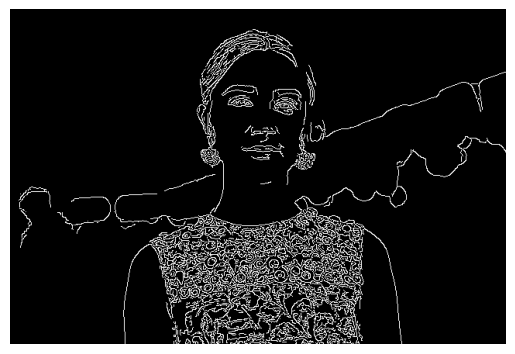

In [102]:
canny_iphone = cv2.Canny(I_iphone, 100, 200)
plt.imshow(canny_iphone, cmap='gray')
plt.axis('off')
plt.show()

canny_chris = cv2.Canny(I_chris, 100, 200)
plt.imshow(canny_chris, cmap='gray')
plt.axis('off')
plt.show()

canny_chica = cv2.Canny(I_chica, 100, 200)
plt.imshow(canny_chica, cmap='gray')
plt.axis('off')
plt.show()

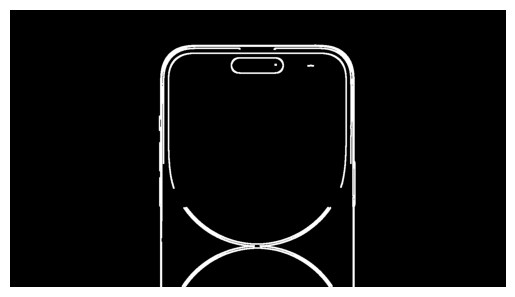

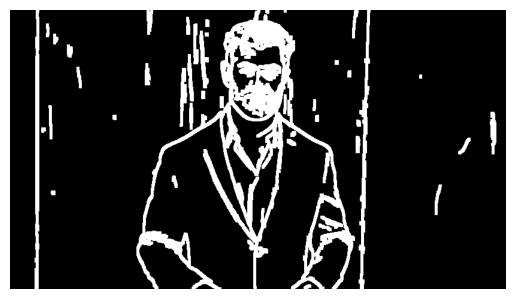

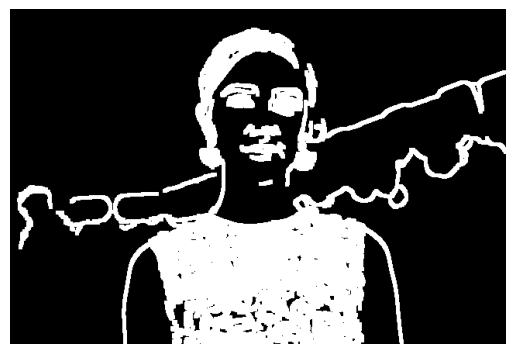

In [103]:
kernel_5x5 = np.ones((5, 5), np.uint8)
dilated_iphone = cv2.dilate(canny_iphone, kernel_5x5, iterations=1)
plt.imshow(dilated_iphone, cmap='gray')
plt.axis('off')
plt.show()

dilated_chris = cv2.dilate(canny_chris, kernel_5x5, iterations=1)
plt.imshow(dilated_chris, cmap='gray')
plt.axis('off')
plt.show()

dilated_chica = cv2.dilate(canny_chica, kernel_5x5, iterations=1)
plt.imshow(dilated_chica, cmap='gray')
plt.axis('off')
plt.show()

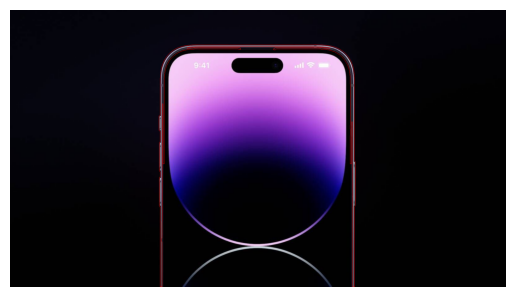

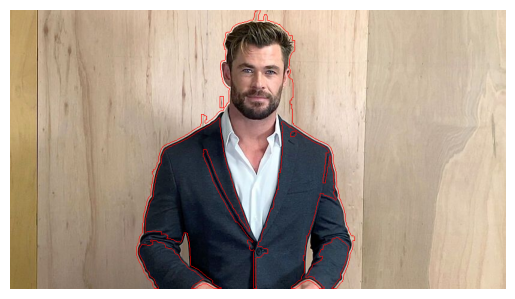

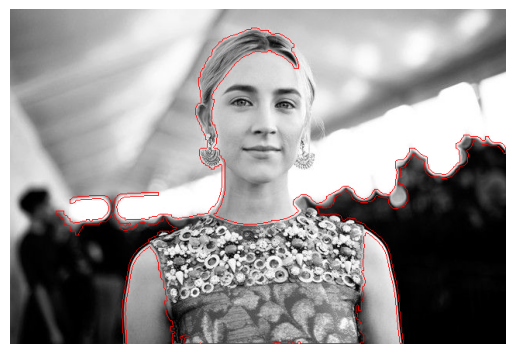

In [104]:
contorno_iphone, _ = cv2.findContours(dilated_iphone, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
contorno_chris, _ = cv2.findContours(dilated_chris, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
contorno_chica, _ = cv2.findContours(dilated_chica, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)

objetos_iphone = imagen_iphone.copy()
cv2.drawContours(objetos_iphone, [max(contorno_iphone, key=cv2.contourArea)], -1, 255, thickness=1)
plt.imshow(objetos_iphone)
plt.axis('off')
plt.show()

objetos_chris = imagen_chris.copy()
cv2.drawContours(objetos_chris, [max(contorno_chris, key=cv2.contourArea)], -1, 255, thickness=1)
plt.imshow(objetos_chris)
plt.axis('off')
plt.show()

objetos_chica = imagen_chica.copy()
cv2.drawContours(objetos_chica, [max(contorno_chica, key=cv2.contourArea)], -1, 255, thickness=1)
plt.imshow(objetos_chica)
plt.axis('off')
plt.show()

In [105]:
objetos_iphone = objetos_iphone/255
objetos_chris = objetos_chris/255
objetos_chica = objetos_chica/255

segmentada_iphone = np.zeros(imagen_iphone.shape)
segmentada_chris = np.zeros(imagen_chris.shape)
segmentada_chica = np.zeros(imagen_chica.shape)

segmentada_iphone[:,:,0] = objetos_iphone[:,:,0] + 255 * (objetos_iphone[:,:,0]==0)
segmentada_iphone[:,:,1] = objetos_iphone[:,:,1] + 255 * (objetos_iphone[:,:,1]==0)
segmentada_iphone[:,:,2] = objetos_iphone[:,:,2] + 255 * (objetos_iphone[:,:,2]==0)

segmentada_chris[:,:,0] = objetos_chris[:,:,0] + 255 * (objetos_chris[:,:,0]==0)
segmentada_chris[:,:,1] = objetos_chris[:,:,1] + 255 * (objetos_chris[:,:,1]==0)
segmentada_chris[:,:,2] = objetos_chris[:,:,2] + 255 * (objetos_chris[:,:,2]==0)

segmentada_chica[:,:,0] = objetos_chica[:,:,0] + 255 * (objetos_chica[:,:,0]==0)
segmentada_chica[:,:,1] = objetos_chica[:,:,1] + 255 * (objetos_chica[:,:,1]==0)
segmentada_chica[:,:,2] = objetos_chica[:,:,2] + 255 * (objetos_chica[:,:,2]==0)

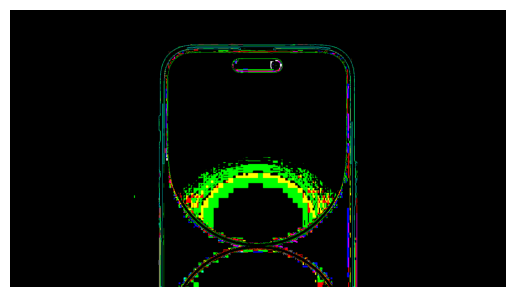

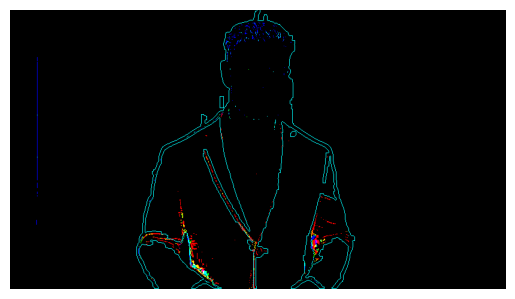

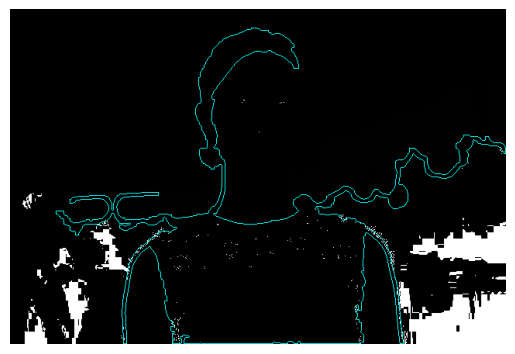

In [106]:
segmentada_iphone = segmentada_iphone.astype(np.uint8)
segmentada_chris = segmentada_chris.astype(np.uint8)
segmentada_chica = segmentada_chica.astype(np.uint8)

plt.imshow(segmentada_iphone)
plt.axis('off')
plt.show()

plt.imshow(segmentada_chris)
plt.axis('off')
plt.show()

plt.imshow(segmentada_chica)
plt.axis('off')
plt.show()